In [14]:
import pandas as pd
import matplotlib.pyplot as plt

member_df = pd.read_csv('members.csv')
kpi_table = pd.read_csv('kpi_summary.csv')
display(
    member_df.head(),
    kpi_table
)

,Membership_Type,Current_Member,Hold_Status,Hold_Duration_Days,Age,Age_Group,Membership_Duration_Days,Monthly_Dues,Sign_Up_Date,Cancellation_Date
0,Full Access,False,NaN,NaN,36,Adult,254,240,2024-11-20 00:00:00,2025-08-01 22:00:00
1,Full Access,True,True,39.0,14,Adult,54,240,2026-04-19 22:00:00,NaN
2,Full Access,True,False,NaN,5,Toddler,237,240,2025-10-18 22:00:00,NaN
3,Full Access,False,NaN,NaN,6,Child,445,240,2024-12-21 00:00:00,2026-03-11 22:00:00
4,1x per week,True,True,34.0,48,Adult,674,160,2024-08-07 22:00:00,NaN


,index,Membership_Type,Membership_Duration_Days,Churn Rate,LTV,Hold_Duration_Days
0,0,1x per week,285.00,54.25%,1520.02,47.25
1,1,Full Access,293.82,53.09%,2350.57,48.58


In [15]:
member_df['Membership_Duration_Months'] = (member_df['Membership_Duration_Days'] / 30).round(2)

**Revenue Analysis**

LTV Per Member

In [16]:
print(kpi_table['LTV'].mean().round(2))

1935.3


LTV By Membership Type

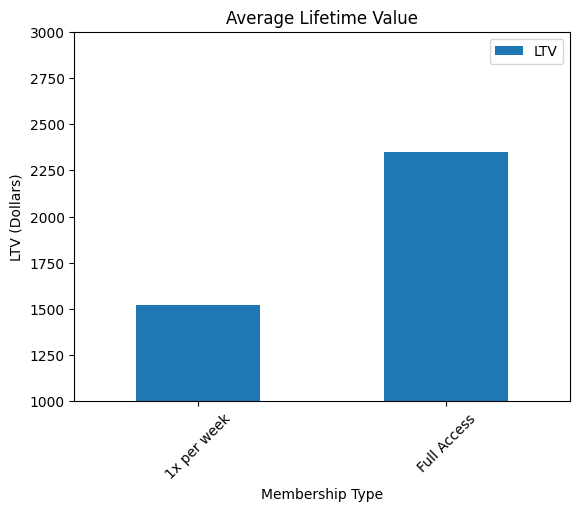

In [17]:
kpi_table.plot(
    kind='bar',
    x='Membership_Type',
    y='LTV'
)
plt.title('Average Lifetime Value')
plt.xlabel('Membership Type')
plt.ylabel('LTV (Dollars)')
plt.xticks(rotation=45)
plt.ylim(1000,3000)
plt.show()

LTV By Age Group

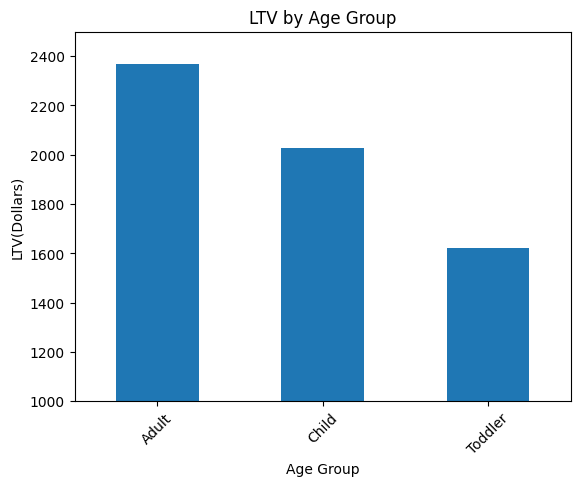

In [18]:
member_df['LTV'] = (member_df['Monthly_Dues'] * member_df['Membership_Duration_Months']).round(2)
ltv_age = (
    member_df.groupby('Age_Group')
    ['LTV']
    .mean()
    .round(2)
)
ltv_age.plot(kind='bar')
plt.title('LTV by Age Group')
plt.xlabel('Age Group')
plt.ylabel('LTV(Dollars)')
plt.ylim(1000,2500)
plt.xticks(rotation=45)
plt.show()

**Revenue Analysis Key Findings and Recommendations:**
The average lifetime value (LTV) per member is approximately $1,935. Full Access members generate approximately 54.6% more revenue over the course of their membership, with an average LTV of $2,350 compared to $1,520 for 1x-per-week members.

When segmented by age group, Adult members generate the highest average LTV ($2,375), followed by Children ($2,025) and Toddlers ($1,625). These findings suggest that increasing Adult membership enrollment and emphasizing Full Access memberships during the sales process may have a positive impact on long-term revenue generation. Additional data, such as referral or marketing source information, would be required to determine which acquisition channels are most effective at attracting high-value members.

**Retention Analysis**

Average Membership Duration by Age Group and Membership Type

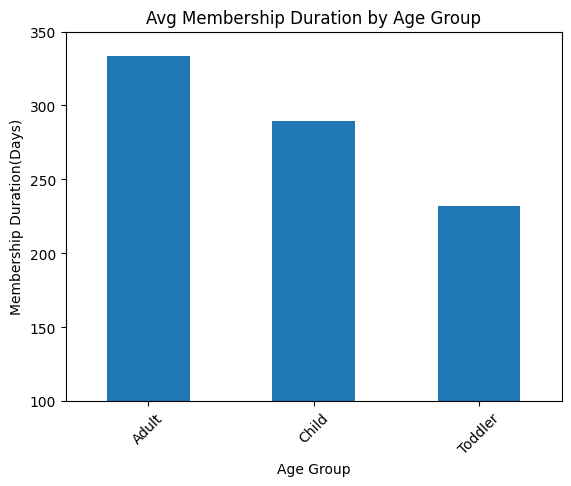

,index,Membership_Type,Membership_Duration_Days,Churn Rate,LTV,Hold_Duration_Days
0,0,1x per week,285.00,54.25%,1520.02,47.25
1,1,Full Access,293.82,53.09%,2350.57,48.58


In [19]:
retention_age = (
    member_df.groupby('Age_Group')
    ['Membership_Duration_Days']
    .mean()
    .round(2)
)
retention_age.plot(kind='bar')
plt.title('Avg Membership Duration by Age Group')
plt.xticks(rotation=45)
plt.xlabel('Age Group')
plt.ylabel('Membership Duration(Days)')
plt.ylim(100,350)
plt.show()

display(kpi_table)

**Retention Analysis Key Findings and Recommendations:**
Adult members have the longest average membership duration at approximately 333 days, compared to 290 days for children and 232 days for toddlers. This finding suggests that adult members exhibit stronger long-term retention and may represent the academy's most stable customer segment.

Membership duration and churn rates are nearly identical across membership plans. Full Access members remain enrolled for an average of 294 days, while 1x-per-week members remain enrolled for approximately 285 days. Similarly, churn rates differ by only about one percentage point (53.1% vs. 54.3%). These findings suggest that membership frequency alone is not a major driver of retention. Given the significantly higher lifetime value generated by Full Access members, management should explore opportunities to encourage upgrades to Full Access memberships while gathering additional data to better understand the factors that influence member retention and cancellation decisions.


**Hold Analysis**

Average Membership Duration by Hold Status

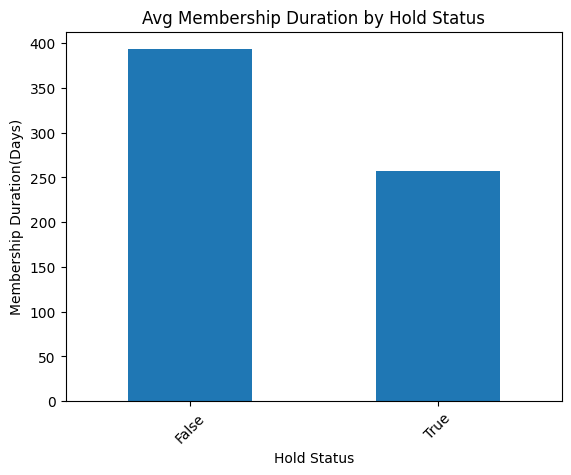

In [20]:
hold_duration = (
    member_df.groupby('Hold_Status')
    ['Membership_Duration_Days']
    .mean()
    .round(2)
)

hold_duration.plot(kind='bar')
plt.title('Avg Membership Duration by Hold Status')
plt.xlabel('Hold Status')
plt.ylabel('Membership Duration(Days)')
plt.xticks(rotation=45)
plt.show()

Churn rate by hold status

Membership Type Distribution

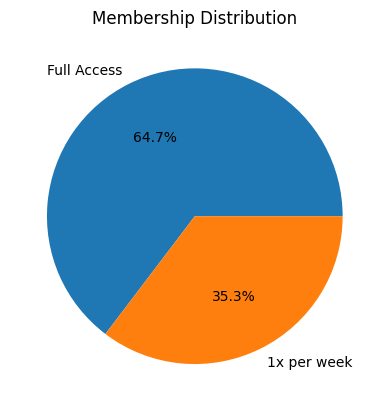

In [26]:
member_df['Membership_Type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
)

plt.ylabel('')
plt.title('Membership Distribution')
plt.show()

Approximately 65% of members are enrolled in the Full Access membership plan, while 35% are enrolled in the 1x-per-week plan. The predominance of Full Access memberships is favorable from a revenue perspective, as these members also generate the highest average lifetime value.